# Colab (A100) runner - Benchmark V2: DSB-2018 (256x256)
FANet_Original vs FANet_MFAD, trained side-by-side with identical split / seed / loss / epochs.

1. **Runtime -> Change runtime type -> A100 GPU**
2. Add Colab *Secrets* (key icon, left sidebar, enable notebook access): `KAGGLE_USERNAME`, `KAGGLE_KEY`
3. Open https://www.kaggle.com/competitions/data-science-bowl-2018/rules and click **I Understand and Accept** with the same account as your Colab Secrets (otherwise 403). Alternative: put `stage1_train.zip` in Drive at `MyDrive/FANet_data/dsb2018/` and the notebook will use it without Kaggle.
4. **Runtime -> Run all**

All checkpoints, CSV and figures are written to Google Drive: `/content/drive/MyDrive/FANet_runs_V2/dsb2018`

In [3]:
# ================================================================
# [Colab Setup] Drive, GPU, deps, dataset download
# ================================================================
import os, sys, subprocess, zipfile, glob as _glob
from google.colab import drive, userdata
drive.mount('/content/drive')

WORK_DIR = "/content/drive/MyDrive/FANet_runs_V2/dsb2018"
DATA_ROOT = "/content/dsb2018"          # local SSD (fast IO), data is NOT stored on Drive
os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(DATA_ROOT, exist_ok=True)

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U",
                "albumentations", "tifffile", "opencv-python-headless"], check=True)

import torch
print("CUDA:", torch.cuda.is_available(), "|",
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
torch.backends.cudnn.benchmark = True
NUM_WORKERS = min(8, os.cpu_count() or 2)

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
import json as _json
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    _json.dump({"username": userdata.get("KAGGLE_USERNAME"), "key": userdata.get("KAGGLE_KEY")}, f)
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

def _unzip_all(root):
    """Extract every .zip under root (except ('stage1_train.zip',)), then delete it."""
    for z in _glob.glob(os.path.join(root, "*.zip")):
        if os.path.basename(z) in ('stage1_train.zip',):
            continue
        print("Extracting", z)
        with zipfile.ZipFile(z) as f:
            f.extractall(root)
        os.remove(z)

DRIVE_DATA = "/content/drive/MyDrive/FANet_runs/dsb2018"   # optional manual copy of the raw files
for _f in _glob.glob(os.path.join(DATA_ROOT, "*")):        # leftovers of an interrupted download
    if _f.endswith(".kaggle-partial") or (os.path.isfile(_f) and os.path.getsize(_f) == 0):
        os.remove(_f)
if not os.listdir(DATA_ROOT):
    if os.path.isdir(DRIVE_DATA) and os.listdir(DRIVE_DATA):
        # Option A: files already on Drive (uploaded once by hand) -> no Kaggle API needed
        print("Copying data from Drive:", DRIVE_DATA)
        subprocess.run(["cp", "-r", DRIVE_DATA + "/.", DATA_ROOT], check=True)
    else:
        # Option B: Kaggle API (new CLI dropped --unzip -> extract in Python)
        cmd = ["kaggle", "competitions", "download", "-c", "data-science-bowl-2018", "-p", DATA_ROOT] + ['-f', 'stage1_train.zip']
        print("$", " ".join(cmd))
        r = subprocess.run(cmd, capture_output=True, text=True)
        print(r.stdout[-2000:], r.stderr[-2000:])
        if r.returncode != 0 or not os.listdir(DATA_ROOT):
            raise RuntimeError(
                "Kaggle download failed (see message above). Fix one of:\n"
                " - 401: Colab Secrets KAGGLE_USERNAME / KAGGLE_KEY wrong or 'Notebook access' not enabled\n"
                " - 403: accept the rules with THE SAME Kaggle account: https://www.kaggle.com/competitions/data-science-bowl-2018/rules\n"
                " - or upload the raw files once to Google Drive: " + DRIVE_DATA)
    _unzip_all(DATA_ROOT)
print("Data ready:", DATA_ROOT, "| entries:", sorted(os.listdir(DATA_ROOT))[:10])


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CUDA: True | NVIDIA A100-SXM4-40GB
Copying data from Drive: /content/drive/MyDrive/FANet_runs/dsb2018
Extracting /content/dsb2018/stage1_test.zip
Extracting /content/dsb2018/stage1_sample_submission.csv.zip
Extracting /content/dsb2018/stage1_solution.csv.zip
Extracting /content/dsb2018/stage2_test_final.zip
Extracting /content/dsb2018/stage2_sample_submission_final.csv.zip
Extracting /content/dsb2018/stage1_train_labels.csv.zip
Data ready: /content/dsb2018 | entries: ['0019c086029dd3be01f72131edb74e21ee995574e6d5c136ea868630b0d73523', '004a078bb44ee55ee7d6f1c19f96b3a0d3b5037746a3a75197dbb0be06da05cf', '005463e6d4a0a0b21161f1d97392f22556fbddba970d9440ae774229308a91ed', '005af293e8e53218ae96746ecf9bb88b511154d4a0b35e4ec6296b4623e15836', '005d47447abac7f7fa0ac56ba82f13edbf485105baf0672504d84b58d562f38b', '00ac87390253a22f6eb67c5771a73050e06200d1aa682fcf1b1e3783b

# FANet vs MFAD Benchmark: DSB-2018

**Purpose:** Head-to-head comparison for IEEE T-MI submission

| Property | Value |
|----------|-------|
| FANet Original | Custom Encoder + SE + MixPool (hard binary gating) |
| MFAD (Proposed) | ResNet-34 + Multi-scale Feedback Attention Decoder + Gradient Decoupling |
| Loss | 0.5×BCE + 0.5×Dice |
| Baseline Dice (Paper) | N/A |
| Metrics | Dice, mIoU, Sensitivity, Specificity, FPR, Precision |


In [4]:
import os, sys, random, time, csv, json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
from PIL import Image
from collections import OrderedDict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models

try:
    import albumentations as A
    HAS_ALBUM = True
except ImportError:
    os.system("pip install -q albumentations")
    import albumentations as A
    HAS_ALBUM = True

try:
    import tifffile as tiff
except ImportError:
    os.system("pip install -q tifffile")
    import tifffile as tiff

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [5]:
# ================================================================
# UniversalDataset — handles jpg/png/tif/gif, auto-binarises masks
# ================================================================
class UniversalDataset(Dataset):
    def __init__(self, images_path, masks_path, image_size, is_train=False):
        self.images_path = list(images_path)
        self.masks_path  = list(masks_path)
        self.image_size  = image_size
        self.is_train    = is_train
        self.n_samples   = len(self.images_path)

        # Paper augmentation suite
        self.transform = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1,
                               rotate_limit=45, p=0.6),
            A.ElasticTransform(p=0.3, alpha=120, sigma=120*0.05,
                               alpha_affine=120*0.03),
            A.GridDistortion(p=0.3),
            A.OpticalDistortion(p=0.3, distort_limit=0.05, shift_limit=0.05),
            A.ToGray(p=0.2),
            A.RandomBrightnessContrast(p=0.3),
            A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.2),
        ])

    def _read_image(self, path):
        if path.lower().endswith('.gif'):
            return np.array(Image.open(path).convert('RGB'))
        img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
        if img is None:
            return np.array(Image.open(path).convert('RGB'))
        if len(img.shape) == 2:
            return np.stack([img]*3, axis=-1)
        if img.shape[2] == 4:
            return cv2.cvtColor(img, cv2.COLOR_BGRA2RGB)
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    def _read_mask(self, path):
        if path.lower().endswith('.gif'):
            return np.array(Image.open(path).convert('L'))
        m = cv2.imread(path, cv2.IMREAD_UNCHANGED)
        if m is None:
            return np.array(Image.open(path).convert('L'))
        if len(m.shape) == 3:
            return cv2.cvtColor(m, cv2.COLOR_BGR2GRAY)
        return m

    def __getitem__(self, index):
        image = self._read_image(self.images_path[index])
        mask  = self._read_mask(self.masks_path[index])

        # Resize
        image = cv2.resize(image, self.image_size, interpolation=cv2.INTER_LINEAR)
        mask  = cv2.resize(mask,  self.image_size, interpolation=cv2.INTER_NEAREST)

        # Augmentation (train only)
        if self.is_train:
            aug = self.transform(image=image, mask=mask)
            image, mask = aug['image'], aug['mask']

        # Normalise image -> [0,1] float32
        image = image.astype(np.float32)
        mx = image.max()
        if mx > 0:
            image = image / (65535.0 if mx > 255 else 255.0)
        image = np.transpose(image, (2, 0, 1))  # HWC -> CHW

        # Binarise mask -> {0, 1}
        mask = mask.astype(np.float32)
        uv = np.unique(mask)
        if len(uv) > 2:
            mask = (mask > (mask.max() + mask.min()) / 2.0).astype(np.float32)
        elif mask.max() > 0:
            mask = (mask == mask.max()).astype(np.float32)
        mask = np.expand_dims(mask, axis=0)

        return image, mask

    def __len__(self):
        return self.n_samples


# ================================================================
# EM Volume Dataset (for Electron Microscopy 3D TIFF)
# ================================================================
class EMVolumeDataset(Dataset):
    def __init__(self, volume, labels, indices, image_size, is_train=False):
        self.volume  = volume
        self.labels  = labels
        self.indices = indices
        self.image_size = image_size
        self.is_train = is_train
        self.transform = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1,
                               rotate_limit=45, p=0.5),
            A.ElasticTransform(p=0.3, alpha=120, sigma=120*0.05,
                               alpha_affine=120*0.03),
            A.GridDistortion(p=0.2),
        ])

    def __getitem__(self, idx):
        i = self.indices[idx]
        img = self.volume[i]
        msk = self.labels[i]

        if len(img.shape) == 2:
            img = np.stack([img]*3, axis=-1)

        img = cv2.resize(img, self.image_size, interpolation=cv2.INTER_LINEAR)
        msk = cv2.resize(msk, self.image_size, interpolation=cv2.INTER_NEAREST)

        if self.is_train:
            aug = self.transform(image=img, mask=msk)
            img, msk = aug['image'], aug['mask']

        img = img.astype(np.float32)
        mx = img.max()
        if mx > 0:
            img = img / (65535.0 if mx > 255 else 255.0)
        img = np.transpose(img, (2, 0, 1))

        msk = msk.astype(np.float32)
        if msk.max() > 0:
            msk = (msk / msk.max()).astype(np.float32)
        msk = np.expand_dims(msk, 0)

        return img, msk

    def __len__(self):
        return len(self.indices)

In [6]:
# ================================================================
# Data Science Bowl 2018 (DSB-2018) — Nuclei Segmentation
# ~670 images, ~80:20 split
# Image size: 256x256
# Masks are provided as separate images per nucleus -> need merging
# ================================================================
import zipfile
import shutil

DATASET_NAME = "DSB-2018"
IMAGE_SIZE = (256, 256)
EPOCHS = 200
BATCH_SIZE = 16
LR = 1e-4

ZIP_PATH = os.path.join(DATA_ROOT, "stage1_train.zip")
ORIG_DIR = "/content/dsb2018_work/stage1_train"
MERGED_MASK_DIR = "/content/dsb2018_work/dsb2018_masks"

if os.path.exists(ZIP_PATH) and not os.path.exists(ORIG_DIR):
    print(f"Extracting {ZIP_PATH}...")
    os.makedirs(ORIG_DIR, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(ORIG_DIR)
elif not os.path.exists(ZIP_PATH) and not os.path.exists(ORIG_DIR):
    print("WARNING: stage1_train.zip not found under", DATA_ROOT)

os.makedirs(MERGED_MASK_DIR, exist_ok=True)

all_imgs = []
all_msks = []

print("Merging individual nucleus masks...")
if os.path.exists(ORIG_DIR):
    folder_names = sorted(os.listdir(ORIG_DIR))
    for folder in tqdm(folder_names, desc="Merging Masks"):
        folder_path = os.path.join(ORIG_DIR, folder)
        if not os.path.isdir(folder_path): continue

        img_file = os.path.join(folder_path, "images", folder + ".png")
        mask_files = glob(os.path.join(folder_path, "masks", "*.png"))

        if not os.path.exists(img_file) or len(mask_files) == 0: continue

        merged_path = os.path.join(MERGED_MASK_DIR, folder + ".png")

        if not os.path.exists(merged_path):
            merged = None
            for mf in mask_files:
                m = np.array(Image.open(mf).convert('L'))
                if merged is None:
                    merged = m
                else:
                    merged = np.maximum(merged, m)
            Image.fromarray(merged).save(merged_path)

        all_imgs.append(img_file)
        all_msks.append(merged_path)

images = all_imgs
masks = all_msks

assert len(images) > 0, "No images found!"

random.seed(42)
combined = list(zip(images, masks))
random.shuffle(combined)
images, masks = zip(*combined)

total = len(images)
split = max(1, int(total * 0.8))
train_x, train_y = list(images[:split]), list(masks[:split])
valid_x, valid_y = list(images[split:]), list(masks[split:])

train_dataset = UniversalDataset(train_x, train_y, IMAGE_SIZE, is_train=True)
valid_dataset = UniversalDataset(valid_x, valid_y, IMAGE_SIZE, is_train=False)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=1, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"DSB-2018: Train={len(train_dataset)}, Val={len(valid_dataset)}")

Extracting /content/dsb2018/stage1_train.zip...
Merging individual nucleus masks...


Merging Masks: 100%|██████████| 670/670 [00:26<00:00, 25.39it/s]

DSB-2018: Train=536, Val=134



/usr/local/lib/python3.13/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_1375/3604339169.py:18: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(p=0.3, alpha=120, sigma=120*0.05,
/tmp/ipykernel_1375/3604339169.py:21: UserWarning: Argument(s) 'shift_limit' are not valid for transform OpticalDistortion
  A.OpticalDistortion(p=0.3, distort_limit=0.05, shift_limit=0.05),
/tmp/ipykernel_1375/3604339169.py:24: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.2),


## Model Definitions
Both architectures are defined inline for reproducibility.

In [7]:
# ================================================================
# FANet Original — Exact reproduction from the paper's codebase
# Custom Encoder/Decoder + SE + MixPool with hard binary gating
# Input: [image, mask] as a list
# ================================================================
class SELayer(nn.Module):
    '''Squeeze-and-Excitation channel attention.'''
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)


class ResidualBlock(nn.Module):
    '''3x3->3x3 Residual block with SE attention.'''
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_c)
        self.conv3 = nn.Conv2d(in_c, out_c, kernel_size=1, padding=0)
        self.bn3 = nn.BatchNorm2d(out_c)
        self.se = SELayer(out_c, out_c)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x1 = self.relu(self.bn1(self.conv1(x)))
        x2 = self.bn2(self.conv2(x1))
        x3 = self.se(self.bn3(self.conv3(x)))
        return self.relu(x2 + x3)


class MixPool_Original(nn.Module):
    '''MixPool with HARD BINARY gating (original FANet behaviour).'''
    def __init__(self, in_c, out_c):
        super().__init__()
        self.fmask = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, 1, kernel_size=1, padding=0),
            nn.Sigmoid()
        )
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_c, out_c // 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_c // 2),
            nn.ReLU(inplace=True)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_c, out_c // 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_c // 2),
            nn.ReLU(inplace=True)
        )

    def forward(self, x, m):
        fmask = self.fmask(x)
        stride_h = m.shape[2] // x.shape[2]
        stride_w = m.shape[3] // x.shape[3]
        m = nn.MaxPool2d((stride_h, stride_w))(m)
        m_fg = m[:, 0:1]

        # HARD BINARY: gradient killed by (> 0.5)
        fmask_g = (fmask > 0.5).float()
        keep = torch.maximum(fmask_g, m_fg)

        x1 = self.conv1(x * keep)
        x2 = self.conv2(x)
        return torch.cat([x1, x2], dim=1)


class EncoderBlock_Orig(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.r1 = ResidualBlock(in_c, out_c)
        self.r2 = ResidualBlock(out_c, out_c)
        self.p1 = MixPool_Original(out_c, out_c)
        self.pool = nn.MaxPool2d((2, 2))

    def forward(self, inputs, masks):
        x = self.r1(inputs)
        x = self.r2(x)
        p = self.p1(x, masks)
        o = self.pool(p)
        return o, x


class DecoderBlock_Orig(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.upsample = nn.ConvTranspose2d(in_c, in_c, kernel_size=4,
                                            stride=2, padding=1)
        self.r1 = ResidualBlock(in_c + in_c, out_c)
        self.r2 = ResidualBlock(out_c, out_c)
        self.p1 = MixPool_Original(out_c, out_c)

    def forward(self, inputs, skip, masks):
        x = self.upsample(inputs)
        x = torch.cat([x, skip], dim=1)
        x = self.r1(x)
        x = self.r2(x)
        return self.p1(x, masks)


class FANet_Original(nn.Module):
    '''FANet with hard binary MixPool gating — exact paper reproduction.'''
    def __init__(self):
        super().__init__()
        self.e1 = EncoderBlock_Orig(3, 32)
        self.e2 = EncoderBlock_Orig(32, 64)
        self.e3 = EncoderBlock_Orig(64, 128)
        self.e4 = EncoderBlock_Orig(128, 256)
        self.d1 = DecoderBlock_Orig(256, 128)
        self.d2 = DecoderBlock_Orig(128, 64)
        self.d3 = DecoderBlock_Orig(64, 32)
        self.d4 = DecoderBlock_Orig(32, 16)
        self.output = nn.Conv2d(16 + 1, 1, kernel_size=1, padding=0)

    def forward(self, x, m_fg=None):
        if m_fg is None:
            m_fg = torch.zeros(x.size(0), 1, x.size(2), x.size(3),
                               device=x.device)
        masks = m_fg
        p1, s1 = self.e1(x, masks)
        p2, s2 = self.e2(p1, masks)
        p3, s3 = self.e3(p2, masks)
        p4, s4 = self.e4(p3, masks)
        d1 = self.d1(p4, s4, masks)
        d2 = self.d2(d1, s3, masks)
        d3 = self.d3(d2, s2, masks)
        d4 = self.d4(d3, s1, masks)
        d5 = torch.cat([d4, masks[:, 0:1]], dim=1)
        return self.output(d5)

In [8]:
# ================================================================
# FANet-MFAD (Proposed) — ResNet-34 + Multi-scale Feedback Attention
# Decoder with Gradient Decoupling (.detach())
# ================================================================
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(out_c)
        self.relu  = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.bn2(self.conv2(self.relu(self.bn1(self.conv1(x))))))


class FANet_MFAD(nn.Module):
    '''Multi-scale Feedback Attention Decoder with Gradient Decoupling.

    Key innovations:
      1. ResNet-34 pre-trained encoder (transfer learning)
      2. 4-channel input (RGB + detached prev_mask) for spatial guidance
      3. Learned gate on prev_mask with .detach() — Feedback Firewall
      4. Multi-scale attention: feat * (1 + att(mask)) at every decoder level
    '''
    def __init__(self):
        super().__init__()
        resnet = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)

        # Encoder stem: accept 4-ch input (RGB + prev_mask)
        self.e1_conv = nn.Conv2d(4, 64, 7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            self.e1_conv.weight[:, :3] = resnet.conv1.weight
            self.e1_conv.weight[:, 3:4] = 0.0
        self.e1_bn   = resnet.bn1
        self.e1_relu = resnet.relu
        self.pool    = resnet.maxpool

        self.e2 = resnet.layer1   # 64
        self.e3 = resnet.layer2   # 128
        self.e4 = resnet.layer3   # 256
        self.b  = resnet.layer4   # 512

        # Decoder with skip connections
        self.up1 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.d1  = ConvBlock(512, 256)
        self.att1 = nn.Sequential(nn.Conv2d(1, 256, 1),
                                  nn.BatchNorm2d(256), nn.Sigmoid())

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.d2  = ConvBlock(256, 128)
        self.att2 = nn.Sequential(nn.Conv2d(1, 128, 1),
                                  nn.BatchNorm2d(128), nn.Sigmoid())

        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.d3  = ConvBlock(128, 64)
        self.att3 = nn.Sequential(nn.Conv2d(1, 64, 1),
                                  nn.BatchNorm2d(64), nn.Sigmoid())

        self.up4 = nn.ConvTranspose2d(64, 64, 2, stride=2)
        self.d4  = ConvBlock(128, 64)
        self.att4 = nn.Sequential(nn.Conv2d(1, 64, 1),
                                  nn.BatchNorm2d(64), nn.Sigmoid())

        self.up5 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.d5  = ConvBlock(32, 32)
        self.att5 = nn.Sequential(nn.Conv2d(1, 32, 1),
                                  nn.BatchNorm2d(32), nn.Sigmoid())

        self.out = nn.Conv2d(32, 1, 1)
        self.learned_gate = nn.Conv2d(1, 1, 1)

    def _mfad(self, feat, prev_mask, att_layer):
        '''Multi-scale Feedback Attention: feat * (1 + att(mask))'''
        m = F.interpolate(prev_mask, size=feat.shape[2:], mode='nearest')
        return feat * (1 + att_layer(m))

    def forward(self, x, prev_mask=None):
        if prev_mask is None:
            prev_mask = torch.zeros(x.size(0), 1, x.size(2), x.size(3),
                                    device=x.device)
        else:
            # GRADIENT DECOUPLING: .detach() severs the Feedback Trap
            prev_mask = torch.sigmoid(self.learned_gate(prev_mask.detach()))

        # Encoder
        s1 = self.e1_relu(self.e1_bn(self.e1_conv(
            torch.cat([x, prev_mask], dim=1))))
        s2 = self.e2(self.pool(s1))
        s3 = self.e3(s2)
        s4 = self.e4(s3)
        b  = self.b(s4)

        # Decoder with multi-scale feedback attention
        d1 = self.d1(torch.cat([self.up1(b), s4], 1))
        d1 = self._mfad(d1, prev_mask, self.att1)

        d2 = self.d2(torch.cat([self.up2(d1), s3], 1))
        d2 = self._mfad(d2, prev_mask, self.att2)

        d3 = self.d3(torch.cat([self.up3(d2), s2], 1))
        d3 = self._mfad(d3, prev_mask, self.att3)

        d4 = self.d4(torch.cat([self.up4(d3), s1], 1))
        d4 = self._mfad(d4, prev_mask, self.att4)

        d5 = self.d5(self.up5(d4))
        d5 = self._mfad(d5, prev_mask, self.att5)

        return self.out(d5)

In [9]:
# ================================================================
# Loss: 0.5*BCE + 0.5*Dice (matches original FANet paper exactly)
# ================================================================
class DiceBCELoss(nn.Module):
    @torch.autocast(device_type='cuda', enabled=False)  # BCE is unsafe under autocast -> run loss in fp32
    def forward(self, inputs, targets, smooth=1):
        inputs, targets = inputs.float(), targets.float()
        probs = torch.sigmoid(inputs).view(-1)
        tgt   = targets.view(-1)
        bce   = F.binary_cross_entropy(probs, tgt, reduction='mean')
        inter = (probs * tgt).sum()
        dice  = 1 - (2. * inter + smooth) / (probs.sum() + tgt.sum() + smooth)
        return 0.5 * bce + 0.5 * dice


# ================================================================
# Metrics — per-image, computed on binarised predictions
# ================================================================
def compute_metrics(y_true_np, y_pred_np):
    '''Compute Dice, mIoU, Sensitivity, Specificity, FPR.

    Args:
        y_true_np: binary GT mask [H, W] or [1, H, W]
        y_pred_np: binary pred mask [H, W] or [1, H, W]
    Returns:
        dict with keys: dice, miou, sensitivity, specificity, fpr, precision
    '''
    yt = y_true_np.flatten().astype(np.float32)
    yp = y_pred_np.flatten().astype(np.float32)

    eps = 1e-7
    tp = np.sum((yt == 1) & (yp == 1))
    fp = np.sum((yt == 0) & (yp == 1))
    fn = np.sum((yt == 1) & (yp == 0))
    tn = np.sum((yt == 0) & (yp == 0))

    dice = (2 * tp) / (2 * tp + fp + fn + eps)
    iou  = tp / (tp + fp + fn + eps)
    sensitivity = tp / (tp + fn + eps)          # = Recall
    specificity = tn / (tn + fp + eps)
    fpr  = fp / (fp + tn + eps)
    precision = tp / (tp + fp + eps)

    return {
        'dice': dice,
        'miou': iou,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'fpr': fpr,
        'precision': precision,
    }

In [10]:
# ================================================================
# Training function — works for both FANet_Original and FANet_MFAD
# ================================================================
def train_model(model, train_loader, valid_loader, model_name,
                epochs=EPOCHS, lr=LR, device=DEVICE):
    #Train a model and return best checkpoint path + training history.#
    criterion = DiceBCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=10, min_lr=1e-6)

    # Mixed precision for speed on T4/P100
    scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))
    use_amp = (device.type == 'cuda')

    ckpt_path = os.path.join(WORK_DIR, f"{model_name}_{DATASET_NAME.replace(' ', '_')}_best.pth")
    latest_path = f"{model_name}_{DATASET_NAME.replace(' ', '_')}_latest.pth"

    best_dice = 0.0
    history = {'train_loss': [], 'val_dice': []}
    start_epoch = 0

    # Resume logic
    resume_paths = [latest_path, f"/kaggle/input/fanet-benchmark-{DATASET_NAME.lower().replace('_', '-')}/{latest_path}", f"/kaggle/input/fanet-benchmark-{DATASET_NAME.lower()}/{latest_path}"]
    for p in resume_paths:
        if os.path.exists(p):
            print(f"[*] Found checkpoint: {p}. Resuming...")
            ckpt = torch.load(p, map_location=device, weights_only=False)
            model.load_state_dict(ckpt['model_state'])
            optimizer.load_state_dict(ckpt['optimizer_state'])
            scheduler.load_state_dict(ckpt['scheduler_state'])
            best_dice = ckpt['best_dice']
            history = ckpt['history']
            start_epoch = ckpt['epoch']

            best_paths = [ckpt_path, f"/kaggle/input/fanet-benchmark-{DATASET_NAME.lower().replace('_', '-')}/{ckpt_path}", f"/kaggle/input/fanet-benchmark-{DATASET_NAME.lower()}/{ckpt_path}"]
            for bp in best_paths:
                if os.path.exists(bp):
                    import shutil
                    if bp != ckpt_path: shutil.copy(bp, ckpt_path)
                    break
            break

    if start_epoch >= epochs:
        print(f"[*] {model_name} already completed {epochs} epochs.")
        return ckpt_path, history

    import time
    if 'GLOBAL_START' not in globals():
        global GLOBAL_START
        GLOBAL_START = time.time()

    for epoch in range(start_epoch, epochs):
        # ---- TRAIN ----
        model.train()
        train_loss = 0.0
        for x, y in tqdm(train_loader,
                         desc=f'[{model_name}] E{epoch+1}/{epochs} Train',
                         leave=False):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda', enabled=use_amp):
                out = model(x)                       # iter 1 (no feedback)
                out = model(x, torch.sigmoid(out))   # iter 2 (with feedback)
                loss = criterion(out, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()

        train_loss /= len(train_loader)

        # ---- VALID ----
        model.eval()
        val_dice_sum = 0.0
        n_val = 0
        with torch.no_grad():
            for x, y in valid_loader:
                x, y = x.to(device), y.to(device)
                with torch.amp.autocast('cuda', enabled=use_amp):
                    out = model(x)
                    out = model(x, torch.sigmoid(out))
                pred = (torch.sigmoid(out).cpu().numpy() > 0.5).astype(np.float32)
                gt   = y.cpu().numpy()
                # Per-image dice
                for b_i in range(pred.shape[0]):
                    m = compute_metrics(gt[b_i], pred[b_i])
                    val_dice_sum += m['dice']
                    n_val += 1

        val_dice = val_dice_sum / max(n_val, 1)
        lr_now = optimizer.param_groups[0]['lr']
        scheduler.step(val_dice)

        history['train_loss'].append(train_loss)
        history['val_dice'].append(val_dice)

        print(f"  [{model_name}] Epoch {epoch+1:03d} | "
              f"LR {lr_now:.1e} | Loss {train_loss:.4f} | "
              f"Val Dice {val_dice:.4f}")

        if val_dice > best_dice:
            best_dice = val_dice
            torch.save(model.state_dict(), ckpt_path)

        torch.save({
            'epoch': epoch + 1,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'scheduler_state': scheduler.state_dict(),
            'best_dice': best_dice,
            'history': history
        }, latest_path)

        if time.time() - GLOBAL_START > 11.5 * 3600:
            print(f"[!] KAGGLE TIME LIMIT REACHED (11.5h). Exiting gracefully.")
            import sys
            sys.exit(0)

    print(f"  [{model_name}] Best Val Dice = {best_dice:.4f}")
    return ckpt_path, history

In [11]:
# ================================================================
# Full Evaluation — loads best checkpoint, computes all metrics
# ================================================================
def evaluate_model(model, ckpt_path, valid_loader, model_name, device=DEVICE):
    '''Load best checkpoint and compute per-image metrics on val set.'''
    model.load_state_dict(torch.load(ckpt_path, map_location=device,
                                     weights_only=True))
    model.eval()

    all_metrics = []
    all_preds   = []
    all_gts     = []
    all_images  = []

    with torch.no_grad():
        for x, y in tqdm(valid_loader,
                         desc=f'[{model_name}] Evaluating', leave=False):
            x, y = x.to(device), y.to(device)
            out = model(x)
            out = model(x, torch.sigmoid(out))  # 2-iter feedback
            pred = (torch.sigmoid(out).cpu().numpy() > 0.5).astype(np.float32)
            gt   = y.cpu().numpy()
            imgs = x.cpu().numpy()

            for b_i in range(pred.shape[0]):
                m = compute_metrics(gt[b_i], pred[b_i])
                all_metrics.append(m)
                all_preds.append(pred[b_i])
                all_gts.append(gt[b_i])
                all_images.append(imgs[b_i])

    # Aggregate
    agg = {}
    for key in all_metrics[0]:
        vals = [m[key] for m in all_metrics]
        agg[key] = {'mean': np.mean(vals), 'std': np.std(vals)}

    return agg, all_metrics, all_images, all_gts, all_preds


def print_results(name, agg):
    '''Pretty-print aggregated results.'''
    print(f"\n{'='*60}")
    print(f"  {name} — Final Results on {DATASET_NAME}")
    print(f"{'='*60}")
    for k, v in agg.items():
        print(f"  {k:>15s}: {v['mean']:.4f} ± {v['std']:.4f}")
    print(f"{'='*60}\n")


# ================================================================
# Qualitative Comparison (side-by-side visualisation)
# ================================================================
def plot_comparison(images_orig, gts_orig, preds_orig,
                    images_mfad, gts_mfad, preds_mfad,
                    n_samples=5):
    #Plot: Image | GT | FANet Mask | MFAD Mask.#
    n = min(n_samples, len(images_orig), len(images_mfad))
    fig, axes = plt.subplots(n, 4, figsize=(16, 4 * n))
    if n == 1:
        axes = axes[np.newaxis, :]

    for i in range(n):
        img = np.transpose(images_orig[i], (1, 2, 0))
        img = np.clip(img, 0, 1)
        gt  = gts_orig[i][0]
        p_orig = preds_orig[i][0]
        p_mfad = preds_mfad[i][0]

        axes[i, 0].imshow(img)
        axes[i, 0].set_title('Input Image' if i == 0 else '')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(gt, cmap='gray')
        axes[i, 1].set_title('Ground Truth' if i == 0 else '')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(p_orig, cmap='gray')
        axes[i, 2].set_title('FANet Original' if i == 0 else '')
        axes[i, 2].axis('off')

        axes[i, 3].imshow(p_mfad, cmap='gray')
        axes[i, 3].set_title('MFAD (Ours)' if i == 0 else '')
        axes[i, 3].axis('off')

    plt.suptitle(f'Qualitative Comparison — {DATASET_NAME}', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(WORK_DIR, f'comparison_{DATASET_NAME.replace(" ", "_")}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


# ================================================================
# Save results to CSV
# ================================================================
def save_benchmark_csv(agg_orig, agg_mfad, dataset_name):
    '''Save benchmark results to CSV.'''
    csv_path = os.path.join(WORK_DIR, f'benchmark_results_{dataset_name.replace(" ", "_")}.csv')
    with open(csv_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['Model', 'Metric', 'Mean', 'Std'])
        for model_name, agg in [('FANet_Original', agg_orig),
                                  ('FANet_MFAD', agg_mfad)]:
            for k, v in agg.items():
                writer.writerow([model_name, k,
                                f"{v['mean']:.6f}", f"{v['std']:.6f}"])
    print(f"Results saved to {csv_path}")
    return csv_path

## Run Benchmark: DSB-2018
Training both models on the same data split, then evaluating.


######################################################################
#  BENCHMARK: DSB-2018
#  Image Size: (256, 256) | Epochs: 200 | LR: 0.0001
#  Train: 536 | Val: 134
######################################################################

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 169MB/s]


FANet Original: 7.72M params
FANet MFAD:     24.46M params

  TRAINING: FANet Original


  [FANet_Orig] Epoch 001 | LR 1.0e-04 | Loss 0.7162 | Val Dice 0.5853


  [FANet_Orig] Epoch 002 | LR 1.0e-04 | Loss 0.6476 | Val Dice 0.7186


...

  [FANet_MFAD] Epoch 197 | LR 1.0e-06 | Loss 0.1298 | Val Dice 0.8300


  [FANet_MFAD] Epoch 198 | LR 1.0e-06 | Loss 0.1399 | Val Dice 0.8262


  [FANet_MFAD] Epoch 199 | LR 1.0e-06 | Loss 0.1309 | Val Dice 0.8530


  [FANet_MFAD] Epoch 200 | LR 1.0e-06 | Loss 0.1409 | Val Dice 0.8324
  [FANet_MFAD] Best Val Dice = 0.8855

  EVALUATION



  FANet Original — Final Results on DSB-2018
             dice: 0.8721 ± 0.1422
             miou: 0.7938 ± 0.1657
      sensitivity: 0.9137 ± 0.1323
      specificity: 0.9782 ± 0.0310
              fpr: 0.0218 ± 0.0310
        precision: 0.8448 ± 0.1597


  FANet MFAD (Proposed) — Final Results on DSB-2018
             dice: 0.8855 ± 0.1232
             miou: 0.8106 ± 0.1491
      sensitivity: 0.9180 ± 0.1319
      specificity: 0.9787 ± 0.0325
              fpr: 0.0213 ± 0.0325
        precision: 0.8686 ± 0.1308

Results saved to /content/drive/MyDrive/FANet_runs_V2/dsb2018/benchmark_results_DSB-2018.csv


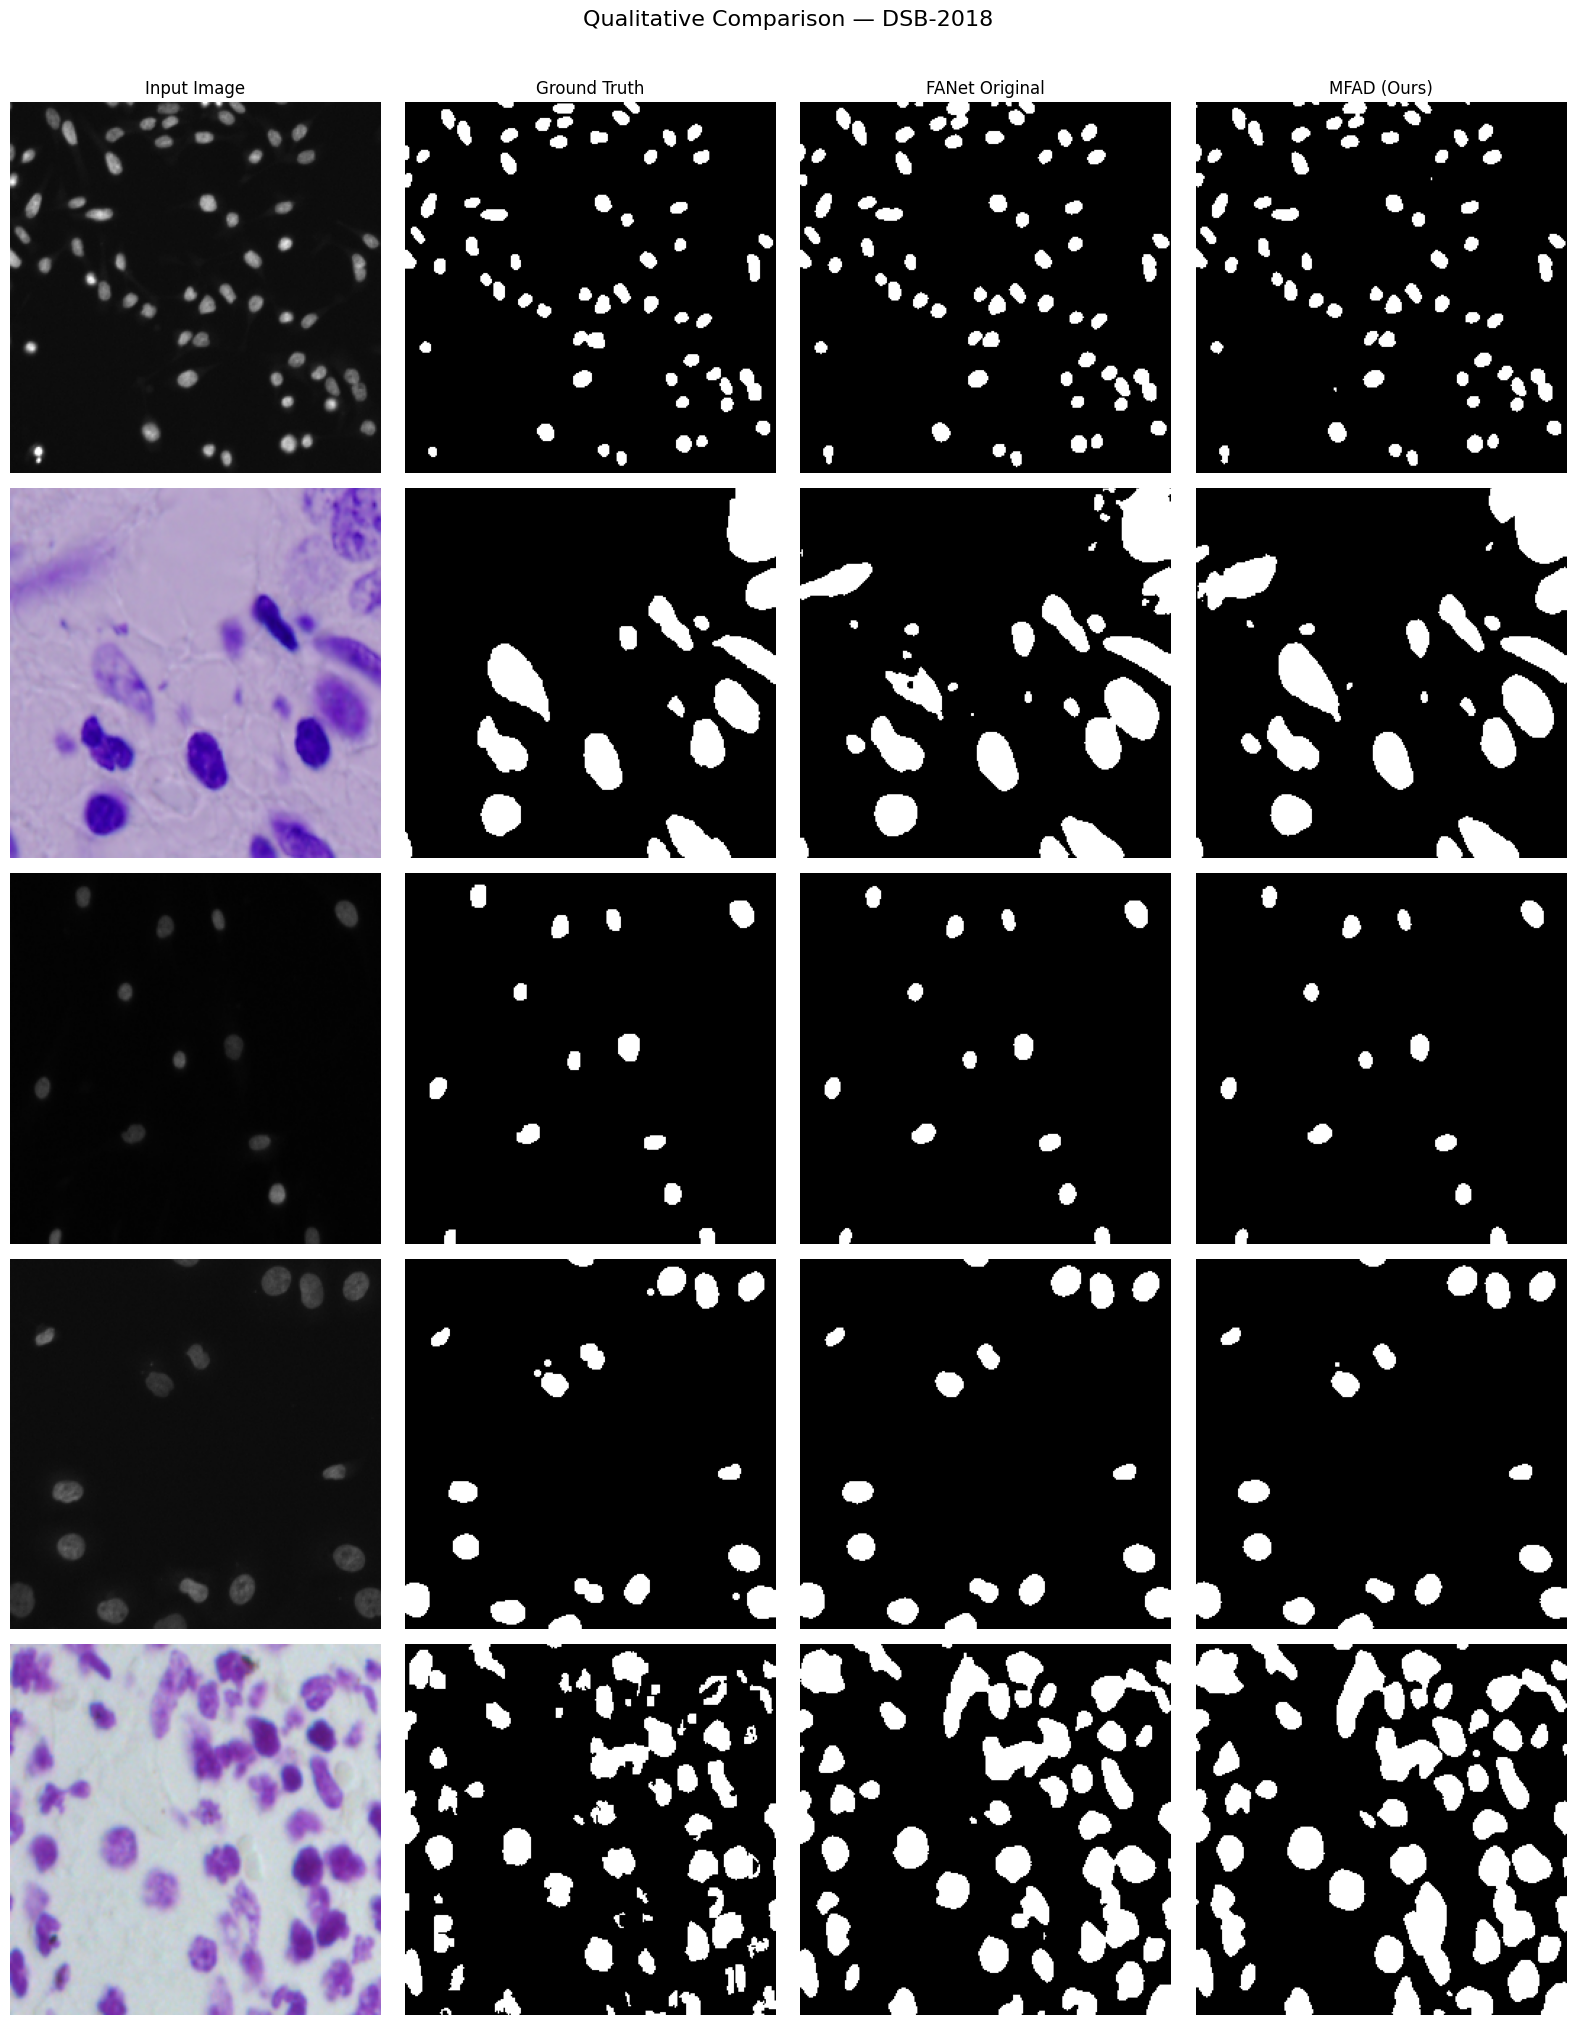

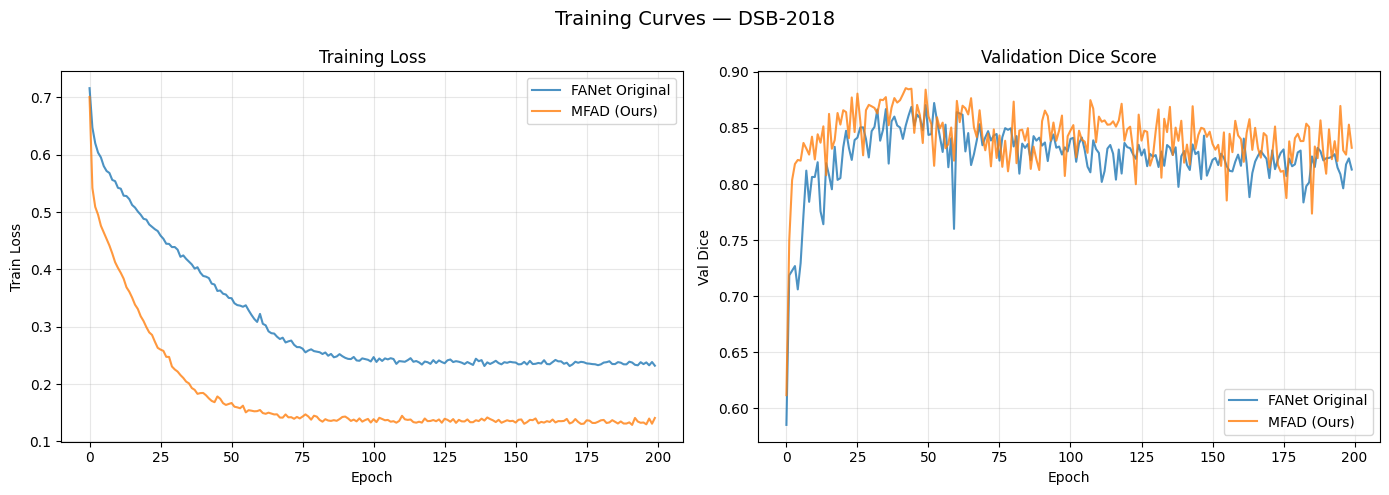


  BENCHMARK SUMMARY — DSB-2018
  Metric          |   FANet Orig |  MFAD (Ours) |      Delta
  ----------------+--------------+--------------+-----------
  dice            |       0.8721 |       0.8855 | +   0.0133
  miou            |       0.7938 |       0.8106 | +   0.0168
  sensitivity     |       0.9137 |       0.9180 | +   0.0044
  specificity     |       0.9782 |       0.9787 | +   0.0005
  fpr             |       0.0218 |       0.0213 |   -0.0005
  precision       |       0.8448 |       0.8686 | +   0.0237


In [12]:
# ================================================================
# RUN BENCHMARK: Train + Evaluate + Compare + Save
# ================================================================
print(f"\n{'#'*70}")
print(f"#  BENCHMARK: {DATASET_NAME}")
print(f"#  Image Size: {IMAGE_SIZE} | Epochs: {EPOCHS} | LR: {LR}")
print(f"#  Train: {len(train_loader.dataset)} | Val: {len(valid_loader.dataset)}")
print(f"{'#'*70}\n")

# ---- 1. Instantiate both models ----
model_orig = FANet_Original().to(DEVICE)
model_mfad = FANet_MFAD().to(DEVICE)

orig_params = sum(p.numel() for p in model_orig.parameters())
mfad_params = sum(p.numel() for p in model_mfad.parameters())
print(f"FANet Original: {orig_params/1e6:.2f}M params")
print(f"FANet MFAD:     {mfad_params/1e6:.2f}M params\n")

# ---- 2. Train FANet Original ----
print("=" * 60)
print("  TRAINING: FANet Original")
print("=" * 60)
ckpt_orig, hist_orig = train_model(model_orig, train_loader, valid_loader,
                                    "FANet_Orig", epochs=EPOCHS, lr=LR)

# ---- 3. Train FANet MFAD ----
print("\n" + "=" * 60)
print("  TRAINING: FANet MFAD (Proposed)")
print("=" * 60)
ckpt_mfad, hist_mfad = train_model(model_mfad, train_loader, valid_loader,
                                    "FANet_MFAD", epochs=EPOCHS, lr=LR)

# ---- 4. Evaluate both models ----
print("\n" + "=" * 60)
print("  EVALUATION")
print("=" * 60)

# Re-create fresh models for loading
model_orig_eval = FANet_Original().to(DEVICE)
model_mfad_eval = FANet_MFAD().to(DEVICE)

agg_orig, metrics_orig, imgs_orig, gts_orig, preds_orig = \
    evaluate_model(model_orig_eval, ckpt_orig, valid_loader, "FANet_Orig")
agg_mfad, metrics_mfad, imgs_mfad, gts_mfad, preds_mfad = \
    evaluate_model(model_mfad_eval, ckpt_mfad, valid_loader, "FANet_MFAD")

print_results("FANet Original", agg_orig)
print_results("FANet MFAD (Proposed)", agg_mfad)

# ---- 5. Save CSV ----
csv_path = save_benchmark_csv(agg_orig, agg_mfad, DATASET_NAME)

# ---- 6. Qualitative comparison ----
plot_comparison(imgs_orig, gts_orig, preds_orig,
                imgs_mfad, gts_mfad, preds_mfad, n_samples=5)

# ---- 7. Training curves ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(hist_orig['train_loss'], label='FANet Original', alpha=0.8)
ax1.plot(hist_mfad['train_loss'], label='MFAD (Ours)', alpha=0.8)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Train Loss')
ax1.set_title('Training Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(hist_orig['val_dice'], label='FANet Original', alpha=0.8)
ax2.plot(hist_mfad['val_dice'], label='MFAD (Ours)', alpha=0.8)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val Dice')
ax2.set_title('Validation Dice Score'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle(f'Training Curves — {DATASET_NAME}', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, f'training_curves_{DATASET_NAME.replace(" ", "_")}.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# ---- 8. Summary ----
print(f"\n{'='*70}")
print(f"  BENCHMARK SUMMARY — {DATASET_NAME}")
print(f"{'='*70}")
print(f"  {'Metric':<15s} | {'FANet Orig':>12s} | {'MFAD (Ours)':>12s} | {'Delta':>10s}")
print(f"  {'-'*15}-+-{'-'*12}-+-{'-'*12}-+-{'-'*10}")
for k in ['dice', 'miou', 'sensitivity', 'specificity', 'fpr', 'precision']:
    vo = agg_orig[k]['mean']
    vm = agg_mfad[k]['mean']
    delta = vm - vo
    sign = '+' if delta >= 0 else ''
    print(f"  {k:<15s} | {vo:>12.4f} | {vm:>12.4f} | {sign}{delta:>9.4f}")
print(f"{'='*70}")